In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates



In [10]:

df = pd.read_csv('18_MF_NB_Test.csv')



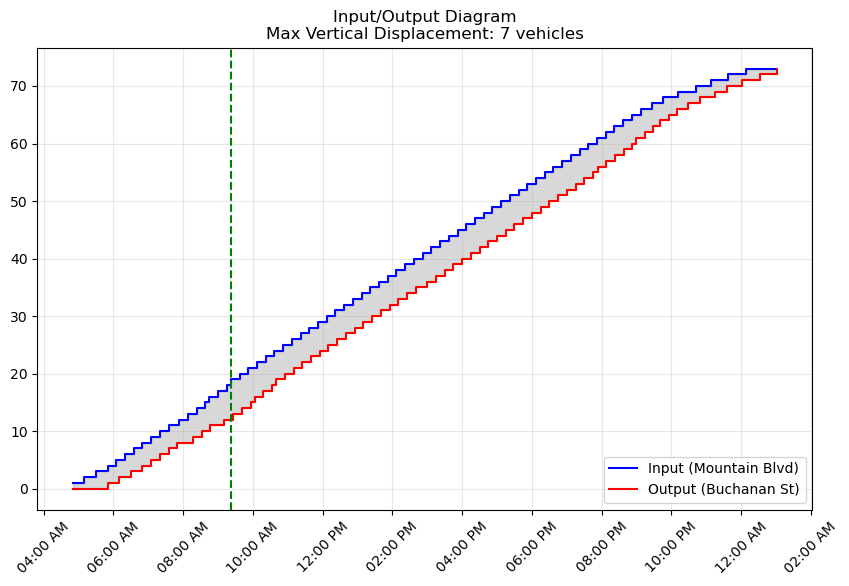

Largest Vertical Displacement: 7 vehicles at 09:22:00 AM


In [ ]:
df['Input'] = pd.to_datetime(df['Input'], format='%I:%M:%S %p')
df['Output'] = pd.to_datetime(df['Output'], format='%I:%M:%S %p')

# 2. MIDNIGHT ROLLOVER
for col in ['Input', 'Output']:
    for i in range(1, len(df)):
        if df.loc[i, col] < df.loc[i-1, col]:
            df.loc[i:, col] += pd.Timedelta(days=1)

# 3. CREATE A UNIFIED TIMELINE
timestamps = sorted(pd.concat([df['Input'], df['Output']]).unique())
results = pd.DataFrame({'Time': timestamps})

# 4. STEP-FUNCTION COUNTING
results['In_Count'] = results['Time'].apply(lambda t: (df['Input'] <= t).sum())
results['Out_Count'] = results['Time'].apply(lambda t: (df['Output'] <= t).sum())
results['Queue'] = results['In_Count'] - results['Out_Count']

# 5. FIND THE MAX
max_q = results['Queue'].max()
max_time = results.loc[results['Queue'].idxmax(), 'Time']

# 6. PLOT
plt.figure(figsize=(10, 6))
plt.step(results['Time'], results['In_Count'], label='Input (Mountain Blvd)', where='post', color='blue')
plt.step(results['Time'], results['Out_Count'], label='Output (Buchanan St)', where='post', color='red')
plt.fill_between(results['Time'], results['In_Count'], results['Out_Count'], step='post', color='gray', alpha=0.3)

plt.axvline(max_time, color='green', linestyle='--')
plt.title(f'Input/Output Diagram\nMax Vertical Displacement: {max_q} vehicles')
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%I:%M %p'))
plt.xticks(rotation=45)
plt.show()

print(f"Largest Vertical Displacement: {max_q} vehicles at {max_time.strftime('%I:%M:%S %p')}")

In [ ]:
%load_ext autoreload
%autoreload 2

# 1. Clean import
from PartA import i_o

# 2. Load data
df = pd.read_csv('18_MF_NB_Test.csv')

# 3. Call the function directly
max_q, max_time = i_o(df)

print(f"Analysis Complete. Max Queue: {max_q}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'i_o' from 'cumulative_curves' (/Users/zorakramer/Transit/cumulative_curves.py)